In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys, os
import pickle
sys.path.append(os.path.abspath('..'))
from mounirood.framework import FrameworkFactory
from mounirood.datasets import get_y, get_dataloader
from mounirood.eval_functions import train, visualize, auc_and_fpr_recall, separabilite, calc_acc


import torch
import torch.nn as nn
from torch.utils.data import  TensorDataset, DataLoader

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
torch.cuda.is_available()

/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

# Near OOD

## HMDB

In [2]:
with open('data_near_ar.pkl', 'rb') as f:
    data = pickle.load(f)["HMDB"]

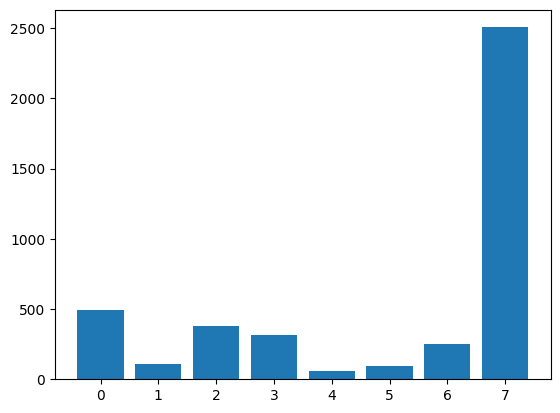

In [83]:
X = np.vstack((data["X_train"], data["X_test"]))
Y = np.vstack((data["y_train"], data["y_test"]))
thresh = 0.5
X = np.where(X > thresh, 1, 0)

Y = np.tile(Y[:, np.newaxis], (1, X.shape[1])).squeeze()
grade = np.where(X==Y, 1, 0).sum(axis=1)

r = X.shape[1]+2
_ = plt.hist(grade, bins=np.arange(r)-0.5, rwidth=0.8)

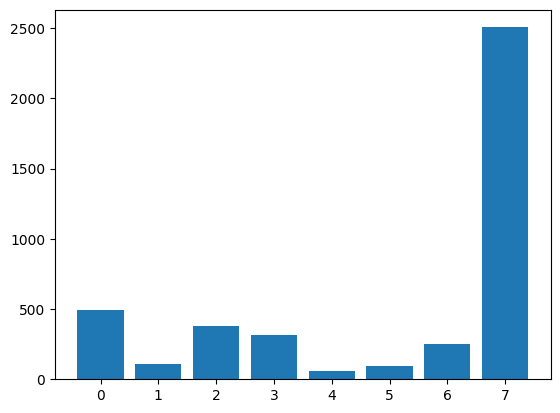

In [39]:
X = np.vstack((data["X_train"], data["X_test"]))
Y = np.vstack((data["y_train"], data["y_test"]))
thresh = 0.5
X = np.where(X > thresh, 1, 0)
X = np.where(X == Y, 1, 0)
grade = np.sum(X, axis=1)
r = X.shape[1]+2
_ = plt.hist(grade, bins=np.arange(r)-0.5, rwidth=0.8)

0,     1             2              3         4         5         6
sans, react tout, react video, react flow, ash tout, ash video, ash flow

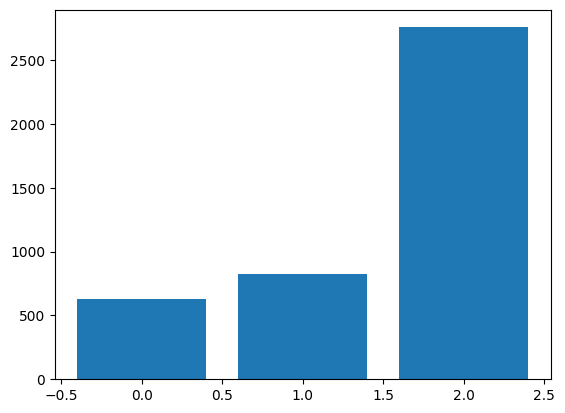

In [38]:
X = np.vstack((data["X_train"][:, [1, 4]], data["X_test"][:, [1, 4]]))
Y = np.vstack((data["y_train"], data["y_test"]))
thresh = 0.5
X = np.where(X > thresh, 1, 0)
X = np.where(X == Y, 1, 0)
grade = np.sum(X, axis=1)
r = X.shape[1]
_ = plt.hist(grade, bins=np.arange(r+2)-0.5, rwidth=0.8)

In [13]:
def majority_vote(X):
    return np.where(np.sum(X, axis=1) > X.shape[1]//2, 1, 0).reshape(-1,1)

In [21]:
X = np.vstack((data["X_train"], data["X_test"]))
Y = np.vstack((data["y_train"], data["y_test"]))
thresh = 0.5
X = np.where(X > thresh, 1, 0)
#X = np.where(X == Y, 1, 0)
X = majority_vote(X)
np.sum((X==Y).astype(int))/len(X)

0.6933142993100166

In [22]:
X = np.vstack((data["X_train"][:, [1, 4]], data["X_test"][:, [1, 4]]))
Y = np.vstack((data["y_train"], data["y_test"]))
thresh = 0.5
X = np.where(X > thresh, 1, 0)
#X = np.where(X == Y, 1, 0)
X = majority_vote(X)
np.sum((X==Y).astype(int))/len(X)

0.6578634308827028

In [27]:
X = np.vstack((data["X_train"][:, [2,3,5,6]], data["X_test"][:, [2,3,5,6]]))
Y = np.vstack((data["y_train"], data["y_test"]))
thresh = 0.5
X = np.where(X > thresh, 1, 0)
#X = np.where(X == Y, 1, 0)
X = majority_vote(X)
np.sum((X==Y).astype(int))/len(X)

0.6852248394004282

In [23]:
X = np.vstack((data["X_train"][:, [1,2,3,4,5,6]], data["X_test"][:, [1,2,3,4,5,6]]))
Y = np.vstack((data["y_train"], data["y_test"]))
thresh = 0.5
X = np.where(X > thresh, 1, 0)
#X = np.where(X == Y, 1, 0)
X = majority_vote(X)
np.sum((X==Y).astype(int))/len(X)

0.6854627646918867

Autres datasets

In [28]:
with open('data_near_ar.pkl', 'rb') as f:
    data = pickle.load(f)["UCF"]
X = np.vstack((data["X_train"], data["X_test"]))
Y = np.vstack((data["y_train"], data["y_test"]))
thresh = 0.5
X = np.where(X > thresh, 1, 0)
#X = np.where(X == Y, 1, 0)
X = majority_vote(X)
np.sum((X==Y).astype(int))/len(X)

0.64909756735548

In [29]:
with open('data_near_ar.pkl', 'rb') as f:
    data = pickle.load(f)["EPIC"]
X = np.vstack((data["X_train"], data["X_test"]))
Y = np.vstack((data["y_train"], data["y_test"]))
thresh = 0.5
X = np.where(X > thresh, 1, 0)
#X = np.where(X == Y, 1, 0)
X = majority_vote(X)
np.sum((X==Y).astype(int))/len(X)

0.6740301724137931